In [1]:
!pip install lime

# ...


In [2]:
# Standard libraries
import os
import re
import tarfile
import random
import requests
from collections import Counter

# Numerical and data handling
import numpy as np
import pandas as pd

# Visualization
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, TensorDataset

# Scikit-learn
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, roc_curve, auc

# LIME and SHAP
import lime
from lime import lime_tabular
from lime.lime_text import LimeTextExplainer
import shap

# Serialization
import joblib


In [3]:
def download_dataset(url, filename='aclImdb_v1.tar.gz'):
    """Download and extract dataset"""
    if not os.path.exists(filename):
        print("Downloading dataset...")
        response = requests.get(url, stream=True)
        response.raise_for_status()
        with open(filename, 'wb') as f:
            for chunk in response.iter_content(chunk_size=8192):
                f.write(chunk)

        print("Extracting...")
        with tarfile.open(filename, 'r:gz') as tar:
            tar.extractall()

    return 'aclImdb'

data_dir = download_dataset("https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz")


In [4]:
def load_imdb_data(path):
    texts, labels = [], []
    for label in ['pos', 'neg']:
        dir_path = os.path.join(path, label)
        for file in os.listdir(dir_path):
            if file.endswith(".txt"):
                with open(os.path.join(dir_path, file), 'r', encoding='utf-8') as f:
                    texts.append(f.read())
                labels.append(1 if label == 'pos' else 0)
    return texts, labels

# Load and combine data
train_texts, train_labels = load_imdb_data(os.path.join(data_dir, 'train'))
test_texts, test_labels = load_imdb_data(os.path.join(data_dir, 'test'))
all_texts = train_texts + test_texts
all_labels = train_labels + test_labels

texts = train_texts + test_texts
labels = train_labels + test_labels

# Use stratified sampling to get 30% balanced subset
subset_texts, _, subset_labels, _ = train_test_split(
    all_texts, all_labels,
    test_size=0.7,  # keep 30%
    stratify=all_labels,
    random_state=42
)

In [5]:
# Tokenizer
def tokenize(text):
    return re.findall(r'\b\w+\b', text.lower())

# Build vocabulary
all_tokens = [token for text in texts for token in tokenize(text)]
vocab_size_limit = 10000
vocab = {word: idx + 2 for idx, (word, _) in enumerate(Counter(all_tokens).most_common(vocab_size_limit))}
vocab["<PAD>"] = 0
vocab["<UNK>"] = 1

# Encode text into token IDs
def encode(text, max_len=200):
    tokens = tokenize(text)
    token_ids = [vocab.get(token, vocab["<UNK>"]) for token in tokens]
    padded = token_ids[:max_len] + [vocab["<PAD>"]] * max(0, max_len - len(token_ids))
    return padded

# Prepare dataset
X = [encode(text) for text in texts]
y = labels

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [6]:
# Convert data to tensors
X_train_tensor = torch.tensor(X_train, dtype=torch.long)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

In [41]:
class SinkhornSortingNetwork(nn.Module):
    def __init__(self, d_model):
        super().__init__()
        self.d_model = d_model

    def forward(self, x, n_iter=10):
        B, N, D = x.shape

        # Create MLP dynamically based on block size N
        ff = nn.Sequential(
            nn.Linear(self.d_model, self.d_model),
            nn.ReLU(),
            nn.Linear(self.d_model, N)
        ).to(x.device)

        logits = ff(x)  # (B, N, N)
        perm_matrix = self.sinkhorn(logits, n_iter)
        return perm_matrix

    def sinkhorn(self, logits, n_iter=10):
        for _ in range(n_iter):
            logits = logits - logits.logsumexp(dim=2, keepdim=True)
            logits = logits - logits.logsumexp(dim=1, keepdim=True)
        return logits.exp()


class SparseSinkhornAttention(nn.Module):
    def __init__(self, d_model, num_heads, block_size):
        super().__init__()
        self.block_size = block_size
        self.num_heads = num_heads
        self.sortnet = SinkhornSortingNetwork(d_model)
        self.attn = nn.MultiheadAttention(d_model, num_heads, batch_first=True)

    def forward(self, x):  # x: (B, seq_len, d_model)
        B, L, D = x.size()
        assert L % self.block_size == 0, f"Sequence length {L} not divisible by block size {self.block_size}"

        num_blocks = L // self.block_size
        x_blocks = x.view(B, num_blocks, self.block_size, D).mean(dim=2)  # (B, num_blocks, D)
        perm = self.sortnet(x_blocks)                                     # (B, num_blocks, num_blocks)
        sorted_blocks = torch.bmm(perm, x_blocks)                         # (B, num_blocks, D)

        # Repeat blocks to reconstruct full sequence approx
        sorted_tokens = sorted_blocks.repeat_interleave(self.block_size, dim=1)  # (B, L, D)
        out, _ = self.attn(sorted_tokens, sorted_tokens, sorted_tokens)  # batch_first=True
        return out  # (B, L, D)

class SinkhornTextClassifier(nn.Module):
    def __init__(self, vocab_size, embedding_dim=128, num_heads=4, block_size=25):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.attn = SparseSinkhornAttention(d_model=embedding_dim, num_heads=num_heads, block_size=block_size)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(embedding_dim, 1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        x = self.embedding(x)       # (B, seq_len, d_model)
        x = self.attn(x)            # (B, seq_len, d_model)
        x = x.permute(0, 2, 1)      # (B, d_model, seq_len)
        x = self.pool(x).squeeze(-1)  # (B, d_model)
        x = self.fc(x)              # (B, 1)
        x = self.sigmoid(x)
        return x


In [42]:
# Model setup
vocab_size = len(vocab)
model = SinkhornTextClassifier(vocab_size)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

Epoch 1/5 - Loss: 0.4372, Accuracy: 0.7955
Epoch 2/5 - Loss: 0.2947, Accuracy: 0.8781
Epoch 3/5 - Loss: 0.2479, Accuracy: 0.9001
Epoch 4/5 - Loss: 0.2206, Accuracy: 0.9128
Epoch 5/5 - Loss: 0.2027, Accuracy: 0.9203
Model saved to model.pth


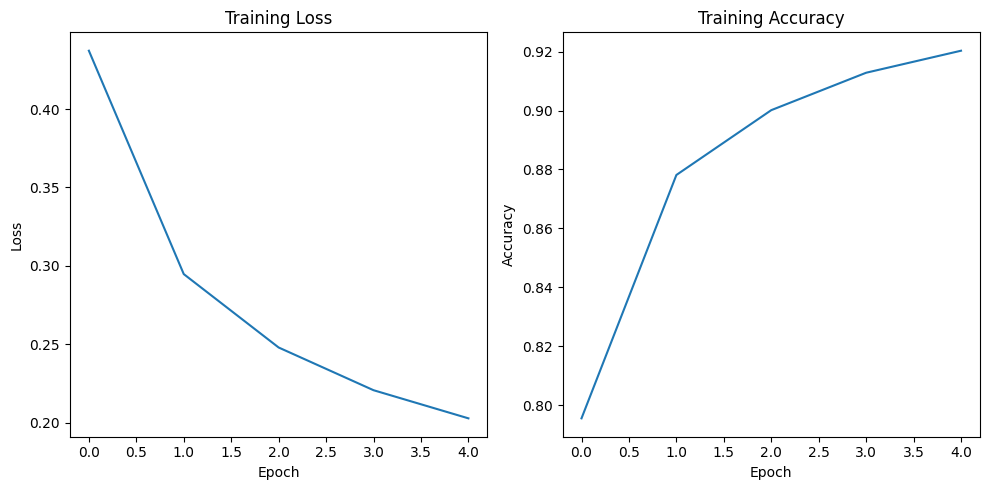

In [43]:
def train_model(model, train_loader, criterion, optimizer, epochs=5, model_save_path='model.pth'):
    model.train()

    train_losses = []
    train_accuracies = []

    for epoch in range(epochs):
        epoch_loss, correct, total = 0.0, 0, 0
        for inputs, labels in train_loader:
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()
            predictions = (outputs > 0.5).float()
            correct += (predictions == labels).sum().item()
            total += labels.size(0)

        # Calculate average loss and accuracy for the epoch
        avg_loss = epoch_loss / len(train_loader)
        accuracy = correct / total

        # Append values to lists
        train_losses.append(avg_loss)
        train_accuracies.append(accuracy)

        print(f"Epoch {epoch + 1}/{epochs} - Loss: {avg_loss:.4f}, Accuracy: {accuracy:.4f}")

    # Save the model
    torch.save(model.state_dict(), model_save_path)
    print(f"Model saved to {model_save_path}")

    # Return the losses and accuracies
    return train_losses, train_accuracies


train_losses, train_accuracies = train_model(model, train_loader, criterion, optimizer, epochs=5)

# Plot the learning curve
plt.figure(figsize=(10, 5))

# Plot Training Loss
plt.subplot(1, 2, 1)
plt.plot(train_losses)
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

# Plot Training Accuracy
plt.subplot(1, 2, 2)
plt.plot(train_accuracies)
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


Test Accuracy: 32.3040
Sample predictions: [np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0), np.float32(1.0)]


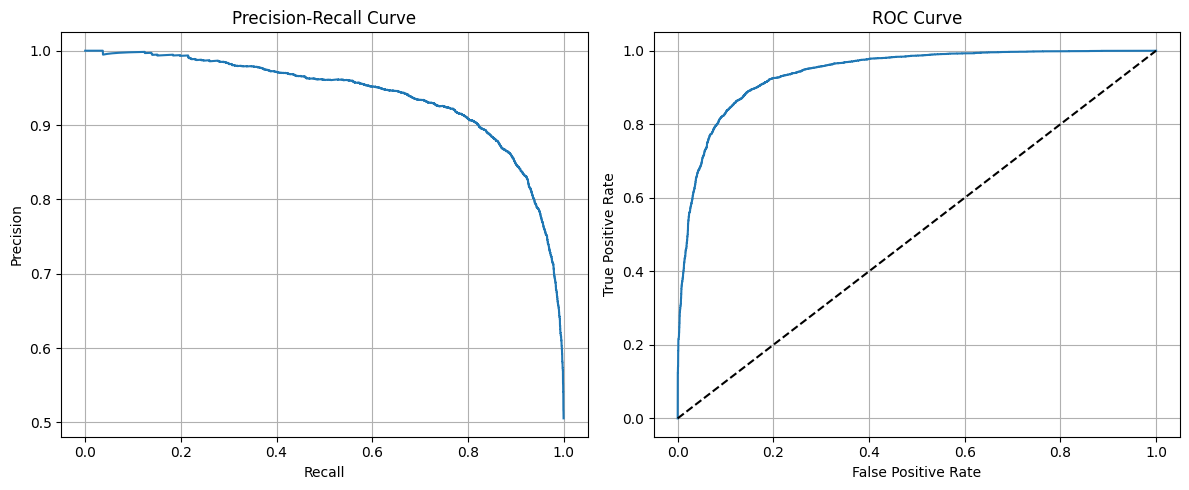

In [44]:
model.eval()
test_loader = DataLoader(TensorDataset(X_test_tensor, y_test_tensor), batch_size=64)

correct = 0
total = 0
all_preds = []
all_probs = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model(inputs).squeeze(1)
        probs = torch.sigmoid(outputs)  # probabilities
        predicted = (probs > 0.5).float()

        correct += (predicted == labels).sum().item()
        total += labels.size(0)

        all_preds.extend(predicted.cpu().numpy())
        all_probs.extend(probs.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

accuracy = correct / total
print(f"Test Accuracy: {accuracy:.4f}")
print("Sample predictions:", all_preds[:10])

# === Plot PR and ROC Curves ===
precision, recall, _ = precision_recall_curve(all_labels, all_probs)
fpr, tpr, _ = roc_curve(all_labels, all_probs)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(recall, precision, label='PR Curve')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f'ROC Curve (AUC = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.grid(True)

plt.tight_layout()
plt.show()

In [45]:
explainer = lime.lime_text.LimeTextExplainer(class_names=['Negative', 'Positive'])

# Function to predict probabilities for LIME
def predict_proba(texts):
    # Tokenize and encode the texts using the BiLSTM model's vocabulary
    encoded_texts = [encode(text) for text in texts]
    text_tensors = torch.tensor(encoded_texts, dtype=torch.long)  # Use torch.long for token IDs

    with torch.no_grad():
        output = model(text_tensors)

    # Modify output to have probabilities for both classes
    probs = output.numpy()

    # Assuming output is a single probability, reshape to (num_samples, 1)
    if probs.ndim == 1:
        probs = probs.reshape(-1, 1)

    # If output_dim is 1, create a 2D array with probabilities for both classes
    if probs.shape[1] == 1:
        probs = np.column_stack([(1 - probs), probs])

    return probs

# Example usage
text_to_explain = "My friends said the movie was absolutely terrible, but, after watching it myself it was great."

# Call explain_instance with labels argument
exp = explainer.explain_instance(text_to_explain, predict_proba, labels=(0, 1), num_features=10)

# Print explanation
print(exp.as_list())

[(np.str_('terrible'), -0.2719459603886917), (np.str_('great'), 0.11194161744465451), (np.str_('it'), 0.043576635695677206), (np.str_('said'), -0.042404799201555377), (np.str_('friends'), -0.040353824919835905), (np.str_('was'), -0.038497007075073766), (np.str_('watching'), -0.03268013506605844), (np.str_('My'), 0.027845842818332384), (np.str_('absolutely'), -0.020645955275033656), (np.str_('after'), 0.013858122074985126)]


In [46]:
exp.show_in_notebook(text=True)


SHAP Explanations:

Example 1:
True label: 1.0
Predicted probability: 0.7863
Word contributions to sentiment:
this: -0.0001
film: -0.0006
is: 0.0006
an: 0.0002
excellent: -0.0031
example: -0.0012
of: 0.0037
what: 0.0004
an: -0.0010
independent: -0.0002
film: 0.0004
can: 0.0022
be: -0.0013
the: 0.0030
director: 0.0026
does: 0.0009
an: 0.0004
excellent: 0.0022
job: -0.0011
of: -0.0022
riding: 0.0011
the: 0.0006
line: 0.0028
between: 0.0007
emotional: 0.0024
and: 0.0043
physical: 0.0016
violence: -0.0012
but: 0.0031
in: 0.0004
the: -0.0019
end: -0.0037
he: -0.0019
remembers: -0.0018
what: -0.0015
so: -0.0025
many: -0.0049
indie: 0.0033
films: -0.0033
forget: 0.0007
he: 0.0009
tells: 0.0024
a: 0.0002
good: 0.0003
story: -0.0015
when: -0.0007
watching: -0.0024
this: -0.0010
film: -0.0011
i: 0.0037
was: 0.0018
reminded: -0.0011
of: 0.0018
how: 0.0000
<UNK>: 0.0037
and: -0.0020
mundane: -0.0015
most: -0.0013
big: -0.0004
budget: -0.0025
hollywood: -0.0008
films: -0.0027
really: -0.0006
have:

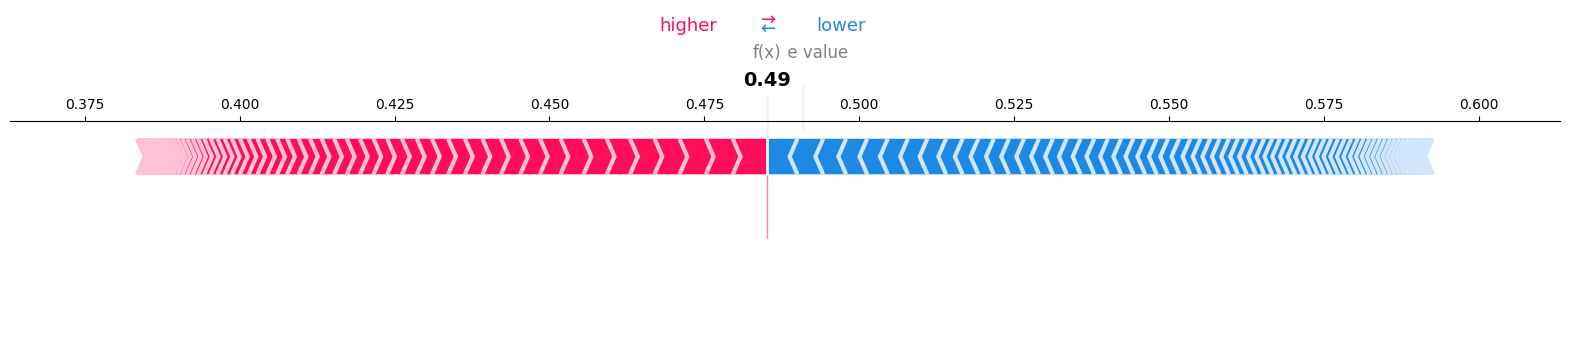


Example 2:
True label: 1.0
Predicted probability: 0.9327
Word contributions to sentiment:
this: 0.0002
<UNK>: 0.0008
from: 0.0008
roman: 0.0008
polanski: 0.0007
clearly: -0.0009
shows: -0.0014
where: 0.0018
his: 0.0018
<UNK>: 0.0001
lay: 0.0004
at: -0.0013
the: -0.0027
time: 0.0006
he: 0.0038
made: 0.0029
it: -0.0000
polanski: 0.0024
himself: 0.0004
plays: 0.0013
a: -0.0005
<UNK>: -0.0034
man: -0.0025
who: 0.0019
<UNK>: 0.0018
a: 0.0024
<UNK>: -0.0007
apartment: -0.0006
where: 0.0017
the: 0.0002
previous: 0.0006
tenant: -0.0036
committed: -0.0003
suicide: 0.0002
he: -0.0003
becomes: -0.0029
obsessed: 0.0012
with: 0.0019
discovering: -0.0007
what: 0.0008
led: 0.0008
her: 0.0013
to: 0.0032
it: -0.0000
to: 0.0005
the: 0.0001
point: -0.0019
that: 0.0007
he: 0.0012
s: -0.0046
dressing: 0.0002
in: -0.0033
drag: -0.0008
and: 0.0000
<UNK>: -0.0023
events: 0.0024
the: 0.0007
way: 0.0043
they: -0.0013
might: 0.0079
have: 0.0011
<UNK>: -0.0007
the: 0.0057
movie: 0.0033
s: -0.0005
unsettling: -0.

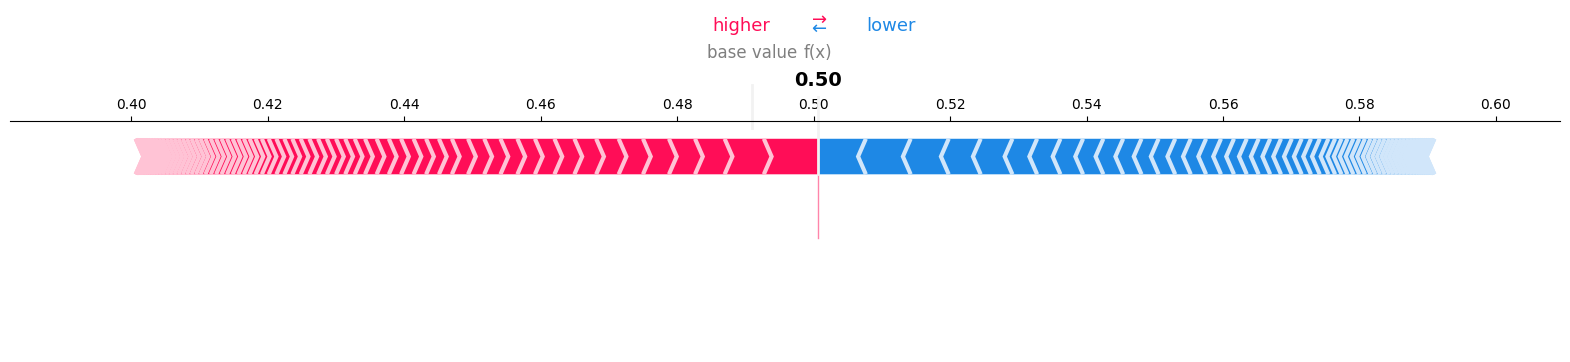


Example 3:
True label: 1.0
Predicted probability: 0.9786
Word contributions to sentiment:
this: 0.0003
is: -0.0018
probably: -0.0005
my: -0.0008
favorite: -0.0020
movie: 0.0008
of: 0.0002
all: -0.0013
time: 0.0043
it: -0.0009
is: -0.0009
perfection: 0.0021
in: 0.0006
its: 0.0006
storytelling: 0.0012
it: 0.0037
will: -0.0015
break: -0.0001
your: 0.0006
heart: 0.0027
not: 0.0021
because: -0.0013
it: 0.0021
s: 0.0001
over: 0.0035
sentimental: -0.0015
but: 0.0002
because: -0.0004
you: -0.0007
will: 0.0024
truly: -0.0002
feel: -0.0031
every: -0.0035
emotion: -0.0027
these: 0.0021
characters: 0.0025
go: -0.0015
through: -0.0004
you: 0.0007
feel: -0.0006
for: -0.0001
<UNK>: 0.0011
because: -0.0008
of: 0.0009
the: 0.0001
hopeless: 0.0002
situation: 0.0010
that: -0.0019
existed: 0.0002
for: -0.0054
young: 0.0025
girls: -0.0000
in: -0.0012
china: 0.0000
at: -0.0001
that: 0.0018
time: -0.0010


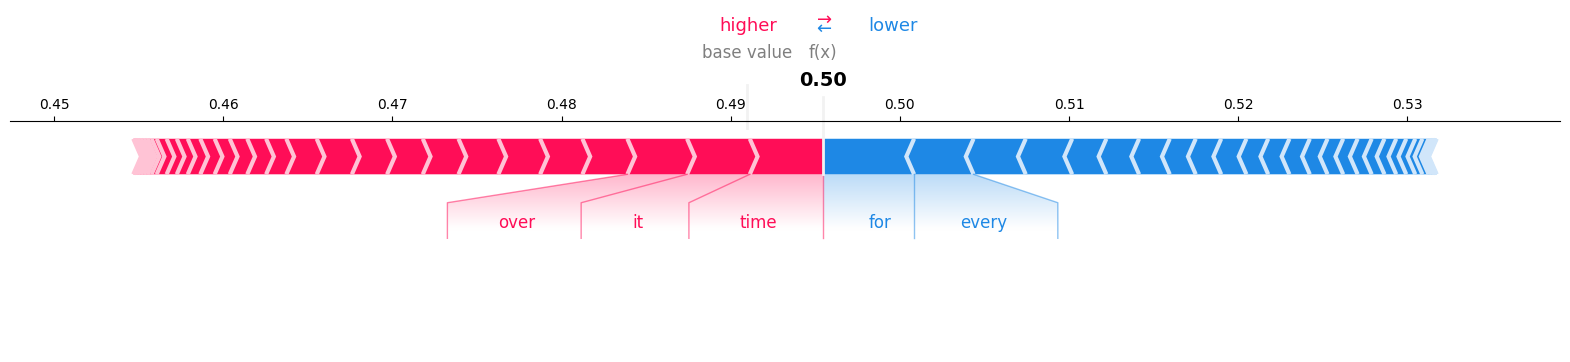


Example 4:
True label: 1.0
Predicted probability: 0.6777
Word contributions to sentiment:
i: 0.0000
love: 0.0008
this: -0.0014
anime: -0.0001
i: -0.0026
was: -0.0008
laughing: 0.0024
my: -0.0000
head: 0.0009
off: -0.0011
with: 0.0007
all: 0.0024
of: 0.0037
the: -0.0035
jokes: 0.0017
and: -0.0011
the: 0.0030
violence: 0.0006
mostly: -0.0003
from: -0.0016
<UNK>: 0.0039
<UNK>: 0.0021
s: -0.0006
reluctant: 0.0028
but: 0.0005
short: -0.0016
<UNK>: 0.0002
<UNK>: -0.0038
is: -0.0036
so: 0.0002
slapstick: -0.0015
however: -0.0039
<UNK>: 0.0019
does: 0.0010
deserve: 0.0019
it: -0.0029
but: -0.0044
he: 0.0032
does: -0.0023
try: 0.0003
his: 0.0011
best: 0.0016
to: 0.0005
make: 0.0001
<UNK>: -0.0023
<UNK>: 0.0005
the: -0.0012
main: 0.0012
character: 0.0017
<UNK>: 0.0042
goes: -0.0037
to: 0.0030
china: -0.0014
to: -0.0001
train: 0.0010
only: -0.0000
to: -0.0037
fall: 0.0004
into: 0.0014
the: -0.0045
cursed: -0.0002
<UNK>: -0.0013
spring: -0.0028
and: -0.0003
turns: 0.0000
into: 0.0038
a: -0.0009
g

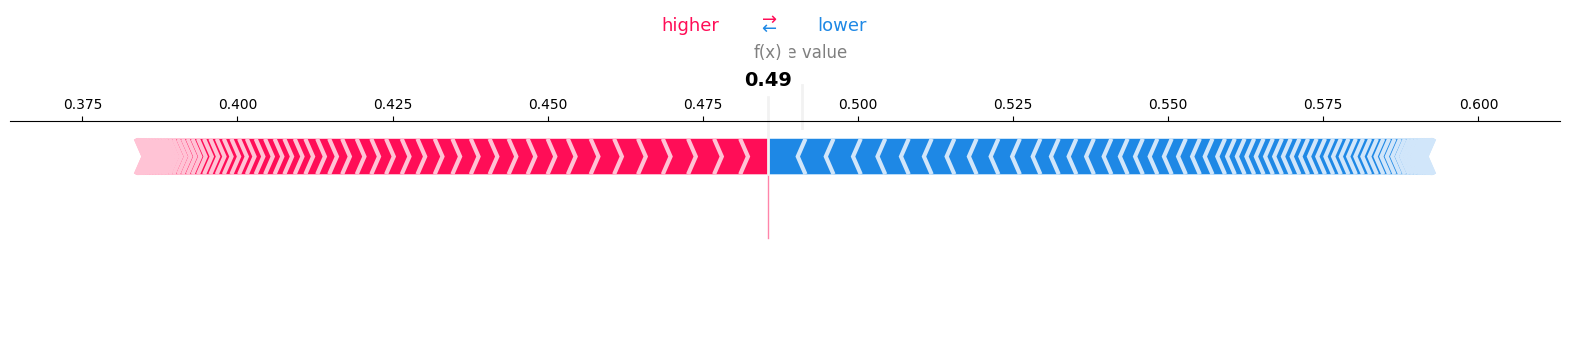


Example 5:
True label: 0.0
Predicted probability: 0.0122
Word contributions to sentiment:
this: -0.0001
is: 0.0005
one: -0.0001
of: -0.0005
the: -0.0014
films: 0.0010
that: 0.0022
killed: -0.0010
the: -0.0007
spaghetti: -0.0006
western: 0.0010
it: -0.0030
not: 0.0006
only: 0.0026
loses: 0.0005
something: 0.0023
in: 0.0032
the: 0.0040
translation: -0.0020
it: 0.0013
is: 0.0005
a: 0.0001
total: 0.0008
chaotic: 0.0003
mess: 0.0054
of: -0.0004
editing: 0.0041
as: 0.0025
well: 0.0035
either: -0.0038
<UNK>: -0.0003
of: 0.0053
it: 0.0085
have: 0.0019
been: 0.0001
edited: 0.0002
out: 0.0021
and: 0.0005
or: 0.0005
re: 0.0023
edited: 0.0009
for: 0.0006
an: -0.0001
english: 0.0009
language: 0.0070
version: 0.0002
in: 0.0001
any: -0.0022
case: -0.0001
it: 0.0063
makes: 0.0022
little: 0.0031
or: -0.0022
no: 0.0001
sense: -0.0012
period: 0.0007
it: -0.0020
makes: 0.0038
the: 0.0015
<UNK>: -0.0058
and: 0.0019
the: 0.0019
eastwood: 0.0041
man: 0.0005
with: 0.0021
no: 0.0029
name: -0.0015
films: -0.00

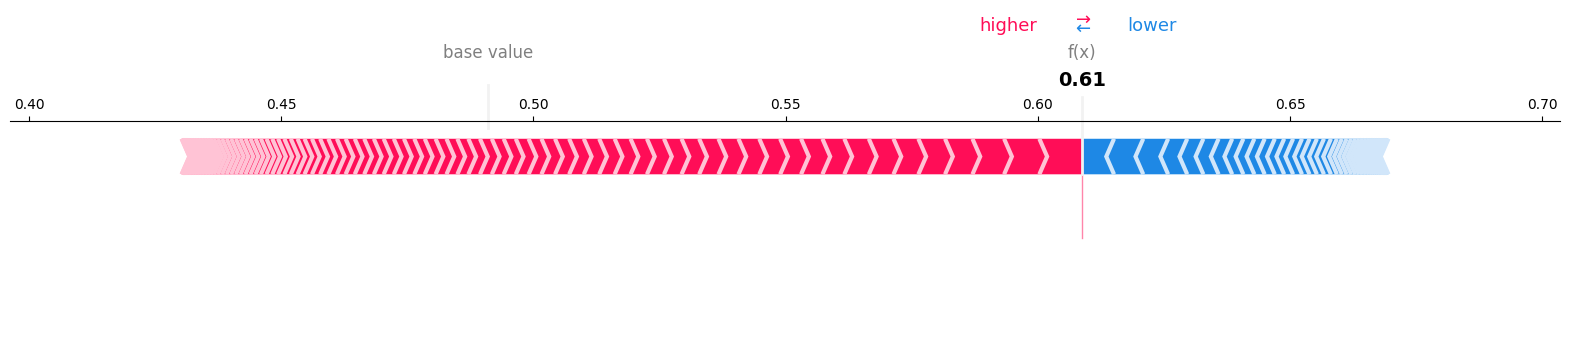

In [49]:
def explain_sinkhorn_with_shap(model, test_loader, vocab, num_examples=5, model_path='model.pth'):
    import shap
    import matplotlib.pyplot as plt
    model.load_state_dict(torch.load(model_path))
    model.eval()

    inv_vocab = {v: k for k, v in vocab.items()}
    pad_token_id = vocab.get("<PAD>", 0)

    # Get test samples
    X_test_tensor, y_test_tensor = test_loader.dataset.tensors
    inputs = X_test_tensor[:num_examples].long()
    labels = y_test_tensor[:num_examples].numpy().flatten()

    background = X_test_tensor[:100].long()

    with torch.no_grad():
        input_emb = model.embedding(inputs).float()         # (B, seq_len, d_model)
        background_emb = model.embedding(background).float()

    # Define wrapper that accepts embedded input
    class FromEmbeddingModel(nn.Module):
        def __init__(self, model):
            super().__init__()
            self.attn = model.attn
            self.pool = model.pool
            self.fc = model.fc
            self.sigmoid = model.sigmoid

        def forward(self, x):  # x is already embedded
            x = self.attn(x)
            x = x.permute(0, 2, 1)
            x = self.pool(x).squeeze(-1)
            x = self.fc(x)
            x = self.sigmoid(x)
            return x

    wrapped_model = FromEmbeddingModel(model)

    explainer = shap.DeepExplainer(wrapped_model, background_emb)
    shap_values = explainer.shap_values(input_emb, check_additivity=False)
    shap_values = shap_values[0]  # (N, seq_len, d_model)

    shap_token_values = shap_values.sum(axis=2)  # (N, seq_len)

    with torch.no_grad():
        preds = model(inputs).squeeze().numpy()

    print("\nSHAP Explanations:")
    for i in range(num_examples):
        token_ids = inputs[i]
        shap_vals = shap_token_values[i]

        # Trim padding
        actual_len = (token_ids != pad_token_id).sum().item()
        words = [inv_vocab.get(token_ids[j].item(), "<UNK>") for j in range(actual_len)]
        shap_trimmed = shap_vals[:actual_len]

        print(f"\nExample {i+1}:")
        print(f"True label: {labels[i]}")
        print(f"Predicted probability: {preds[i]:.4f}")
        print("Word contributions to sentiment:")
        for word, val in zip(words, shap_trimmed):
            print(f"{word}: {val:.4f}")

        min_len = min(len(words), len(shap_trimmed))
        words = words[:min_len]
        shap_trimmed = shap_trimmed[:min_len]

        shap.force_plot(
            explainer.expected_value[0],
            shap_trimmed,
            words,
            matplotlib=True,
            show=False
        )
        plt.savefig(f"shap_sinkhorn_example_{i+1}.png")
        plt.show()
        plt.close()

explain_sinkhorn_with_shap(model, test_loader, vocab, num_examples=5, model_path='model.pth')

In [ ]:
explain_sinkhorn_with_shap(model, train_loader, test_loader, vocab, num_examples=5, model_path='model.pth')




---

